In [26]:
from qiskit import QuantumRegister, QuantumCircuit, AncillaRegister, ClassicalRegister, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeAlgiers

## **4 - bit Quantum Ripple Carry Adder**

In [32]:
def maj_gate():
    qc = QuantumCircuit(3,name="MAJ") # cin, bi, ai(the cout is stored in a)
    qc.cx(2,1)
    qc.cx(2,0)
    qc.ccx(0,1,2)
    return qc.to_gate()

def uma_gate():
    qc = QuantumCircuit(3,name="UMA")
    qc.ccx(0,1,2)
    qc.cx(2,0)
    qc.cx(0,1) #b is the sum
    return qc.to_gate() 

{'00111': 1024}
Resulting Bitstring: 00111
Decimal Sum: 7


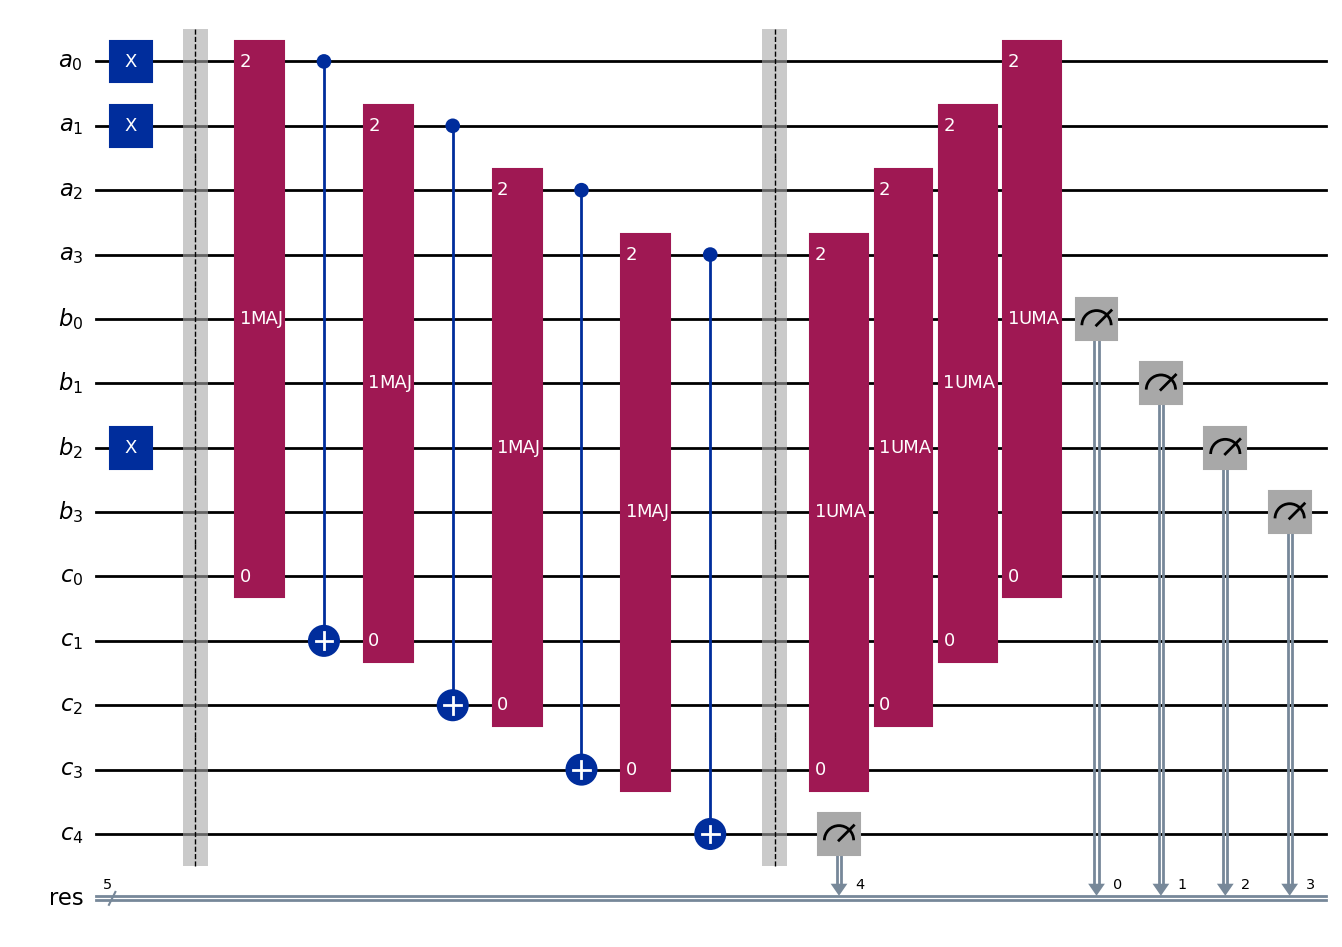

In [39]:
n = 4
a,b = map(int,input("Enter the two input values: ").split())
bin_a, bin_b = bin(a)[2:], bin(b)[2:]  #the op of bin() would 0bxxx to remove 0b -> slicing is applied

reg_a = QuantumRegister(n, name= "a")
reg_b = QuantumRegister(n, name="b")
reg_c = QuantumRegister(n+1, name="c")
measurement = ClassicalRegister(n+1,'res')
qc = QuantumCircuit(reg_a,reg_b,reg_c,measurement)

a_rev = bin_a.zfill(n)[::-1] #to change ip to little endian ordering
b_rev = bin_b.zfill(n)[::-1]

for i in range(n):
    if a_rev[i] == "1" : qc.x(reg_a[i])
    if b_rev[i] == "1" : qc.x(reg_b[i])
qc.barrier()

maj = maj_gate()

for i in range(n):
    qc.append(maj,[reg_c[i],reg_b[i],reg_a[i]])
    qc.cx(reg_a[i],reg_c[i+1]) #moving the cout(a) -> carry bit

qc.barrier()

uma = uma_gate()
for i in range(n-1,-1,-1):
    qc.append(uma,[reg_c[i],reg_b[i],reg_a[i]])
    
for i in range(n):
    qc.measure(reg_b[i],measurement[i])
qc.measure(reg_c[n],measurement[n])

sim = AerSimulator()
t_qc = transpile(qc,sim)
counts = sim.run(t_qc,shots=1024).result().get_counts()
final_bits = max(counts,key=counts.get)

print(counts)
print(f"Resulting Bitstring: {final_bits}")
print(f"Decimal Sum: {int(final_bits, 2)}")

qc.draw('mpl')


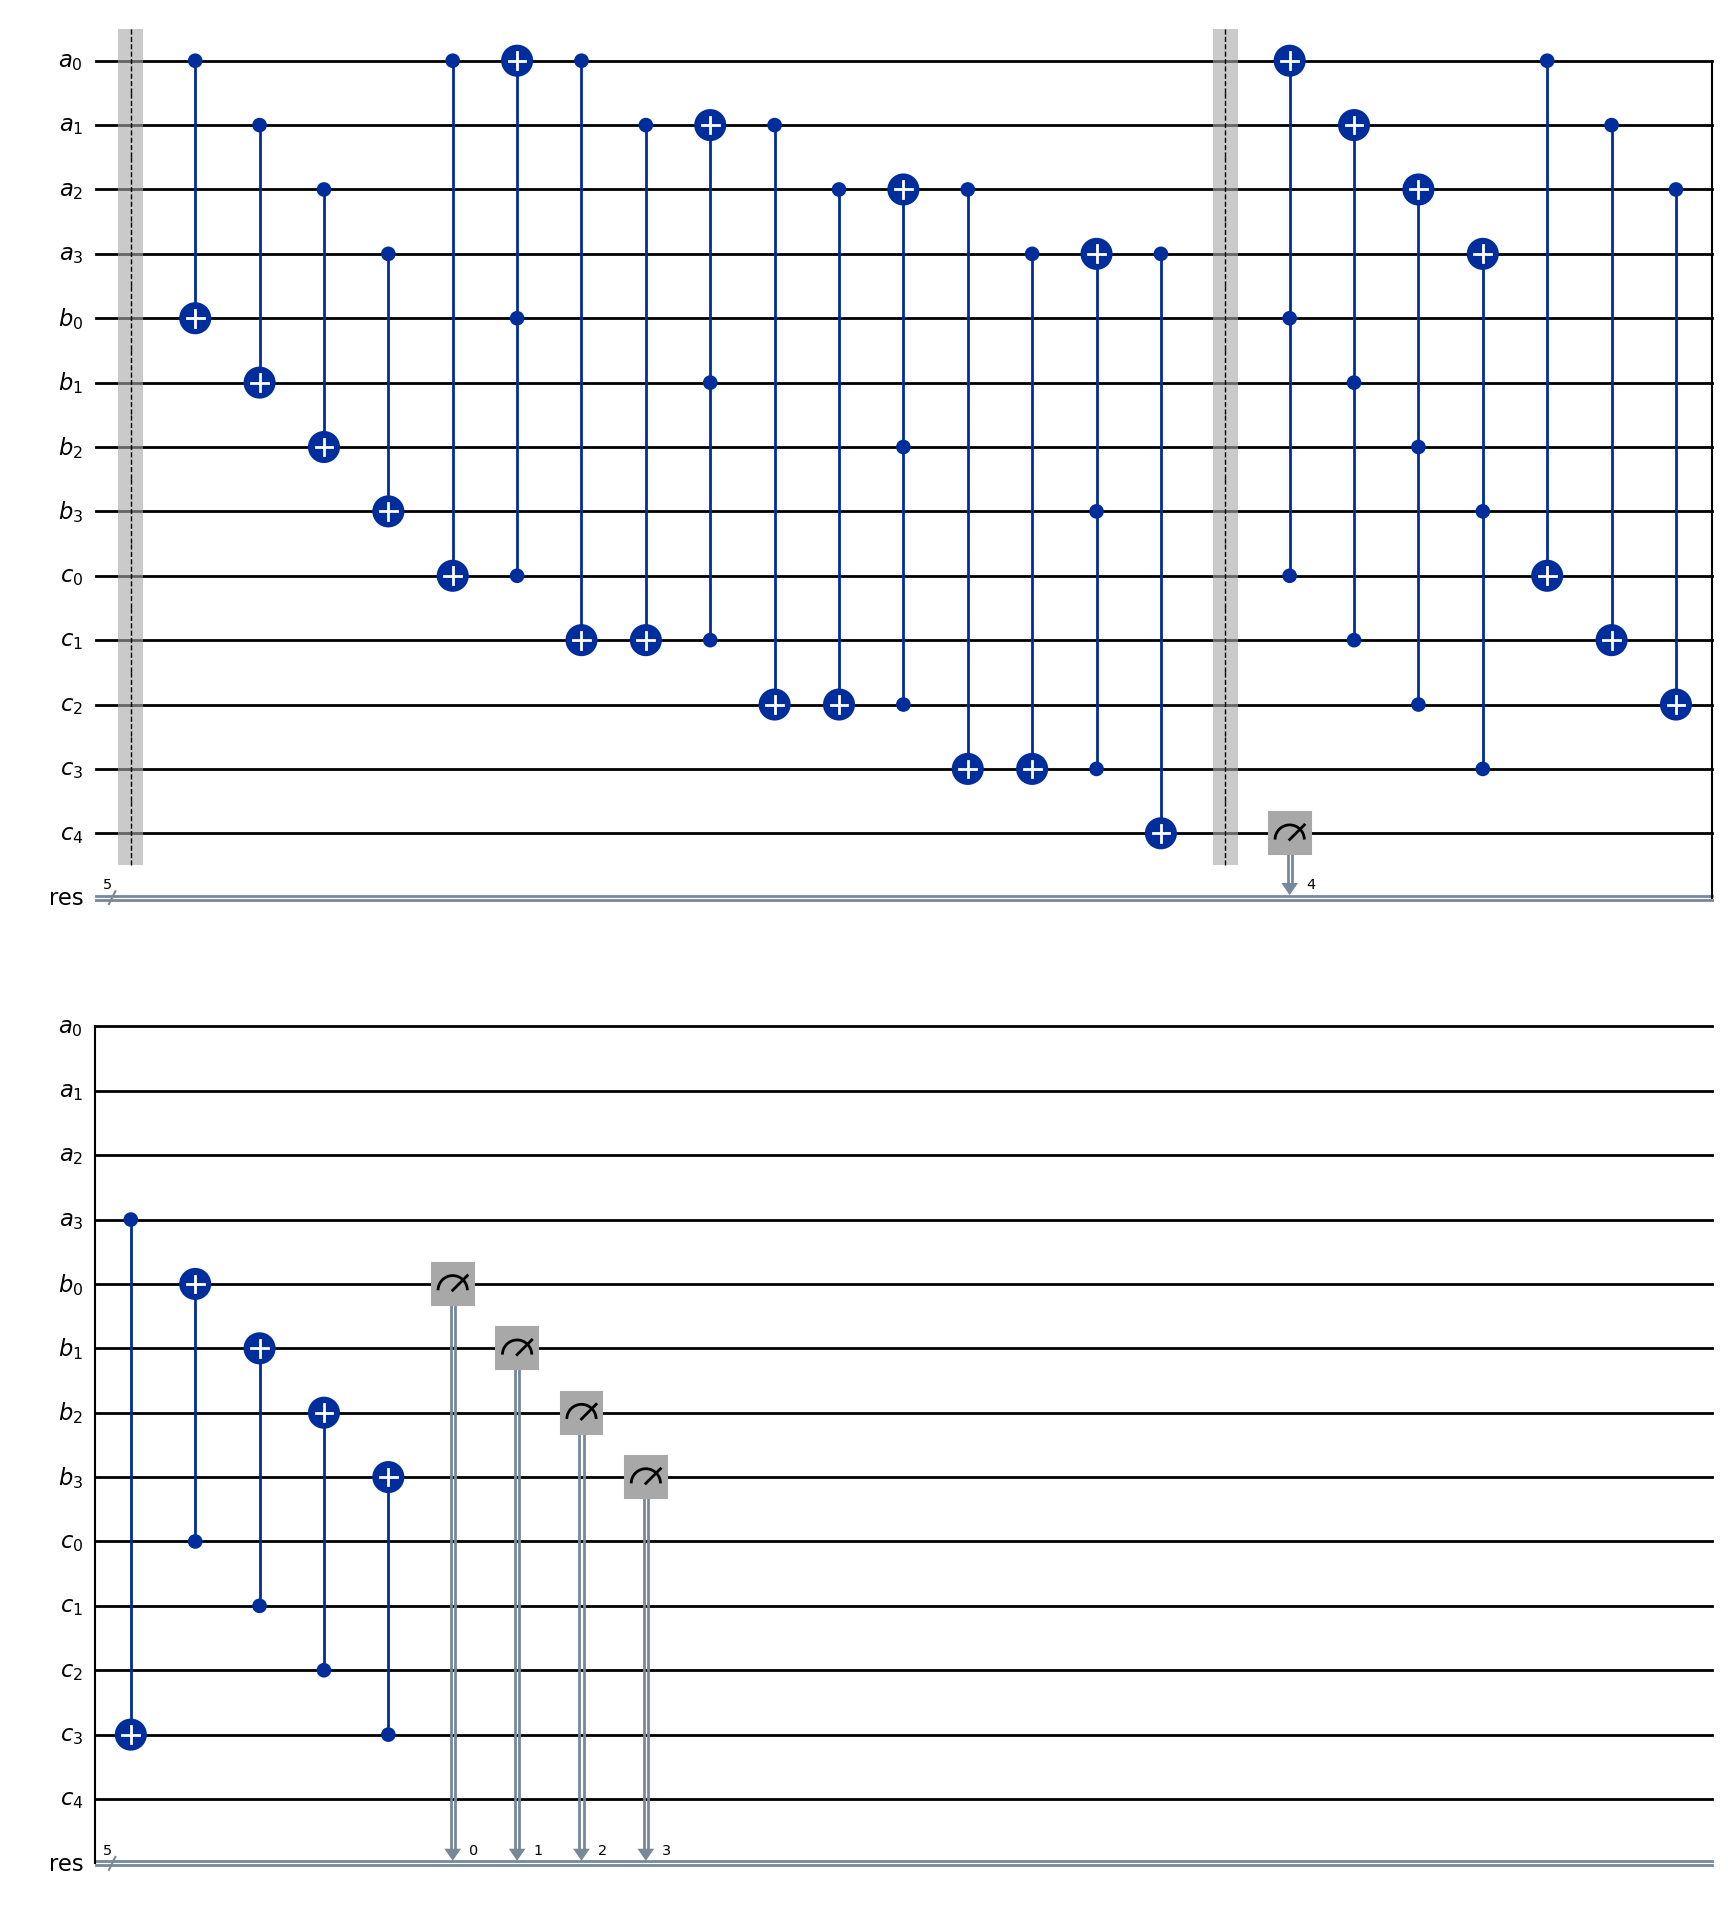

In [30]:
qc.decompose().draw('mpl')

### Quantum Ripple Carry Adder with Noise

In [ ]:
backend = FakeAlgiers()
noise_model = NoiseModel.from_backend(backend=backend)
sim = AerSimulator(noise_model = noise_model)
t_qc = transpile(qc,sim)
counts = sim.run(t_qc,shots = 1024).result().get_counts()

print(counts)

{'00001': 6, '01001': 972, '10001': 1, '11001': 10, '01000': 10, '01101': 12, '01011': 10, '00101': 3}


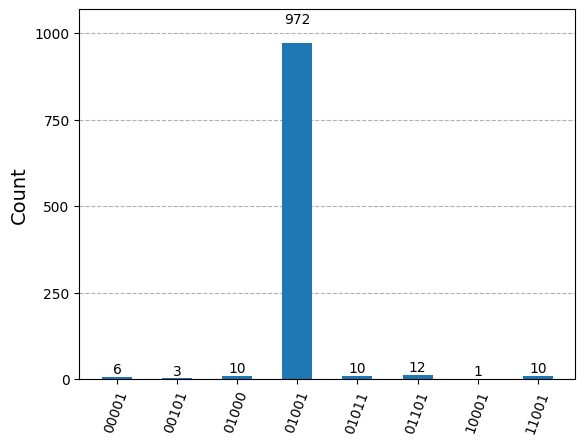

In [38]:
plot_histogram(counts)

## **Quantum Full Adder**

In [2]:
q_in = QuantumRegister(3, name = "input")
q_anc = AncillaRegister(3, name= "ancilla")
q_out = QuantumRegister(2, name = "output")
c_reg = ClassicalRegister(2,"result")

qc = QuantumCircuit(q_in, q_anc, q_out, c_reg)

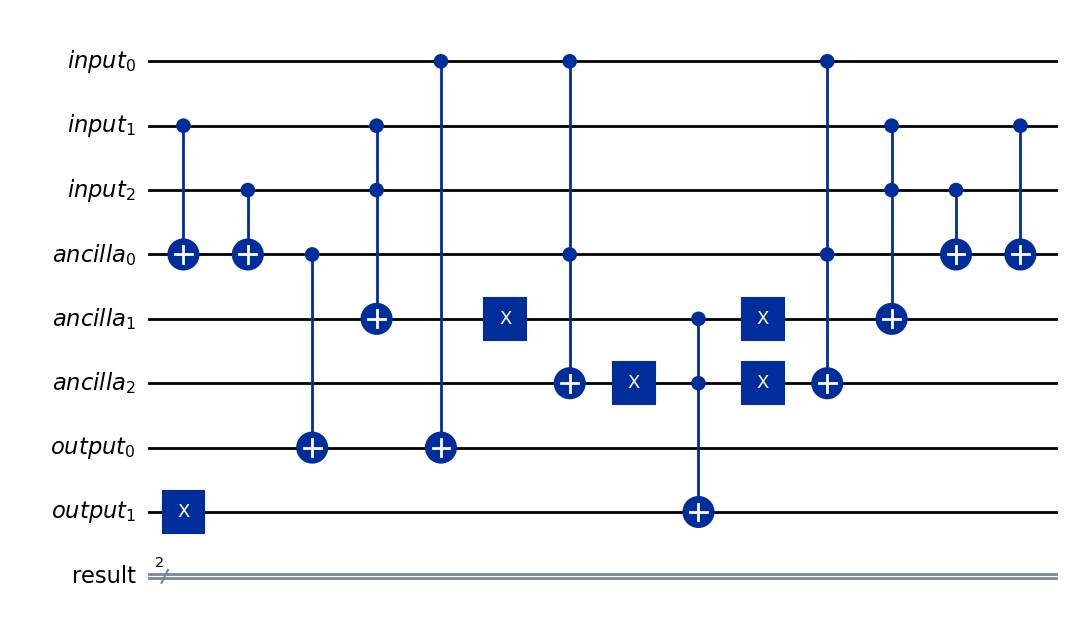

In [3]:
# qc.x(q_in[1]) we can change the input by initializing the qubit to 1
# qc.x(q_in[2])

qc.cx(q_in[1],q_anc[0])
qc.cx(q_in[2],q_anc[0])

qc.cx(q_anc[0],q_out[0])
qc.cx(q_in[0],q_out[0])

qc.ccx(q_in[1],q_in[2],q_anc[1])
qc.ccx(q_in[0],q_anc[0],q_anc[2])

qc.x(q_out[1])
qc.x([q_anc[1],q_anc[2]])
qc.ccx(q_anc[1],q_anc[2],q_out[1])
qc.x([q_anc[1],q_anc[2]])

qc.ccx(q_in[0], q_anc[0], q_anc[2])   
qc.ccx(q_in[1], q_in[2], q_anc[1])    
qc.cx(q_in[2], q_anc[0])               
qc.cx(q_in[1], q_anc[0])   

qc.draw('mpl')

In [4]:
qc.measure(q_out[0],c_reg[0])
qc.measure(q_out[1],c_reg[1])

sim = AerSimulator()
transpiled_qc = transpile(qc, sim)
job = sim.run(transpiled_qc, shots = 1024)
counts = job.result().get_counts()
print(counts)  # for adding two bit 00 = 00, 01 = 01, 10 = 01, 11 = 01 || c_res[0] => Sum, c_res[1] => Cout


{'00': 1024}


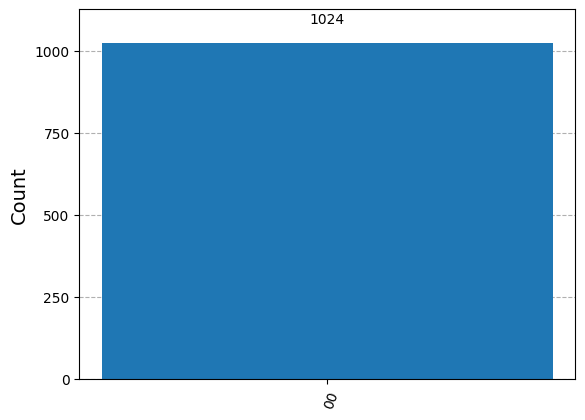

In [5]:
plot_histogram(counts)

### Full Adder implementation with noise

In [7]:
fake_backend  = FakeAlgiers()
noise_model = NoiseModel.from_backend(fake_backend)
sim = AerSimulator(noise_model = noise_model)
transpiled_qc = transpile(qc,sim)
counts = sim.run(transpiled_qc).result().get_counts()
print(counts)

{'00': 952, '10': 58, '11': 1, '01': 13}


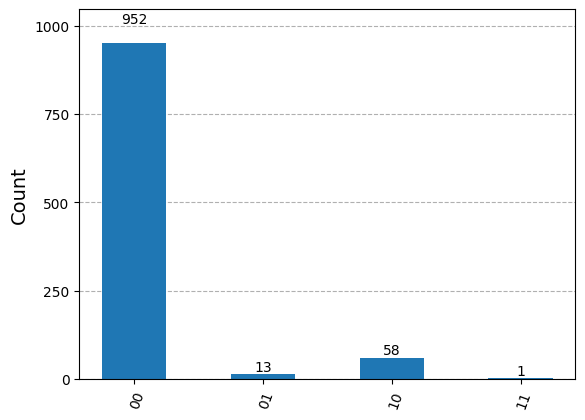

In [8]:
plot_histogram(counts)